In [ ]:
!gdown 1ap6MjL50XkmFpuWzM2MSbdScQ-qR6pER -q

In [ ]:
!pip install ultralytics -q

In [ ]:
!unzip dataset_vehicle_toy.zip -d dataset

Archive:  dataset_vehicle_toy.zip
 extracting: dataset/train/images/frame_00033_jpg.rf.Pmzxzrj33S0oUGagnC20.jpg  
 extracting: dataset/train/images/frame_00054_jpg.rf.TxB94CGY9KYBzq9I1k0k.jpg  
 extracting: dataset/train/images/frame_00052_jpg.rf.RhAS7xjofDvL5rdR8T2V.jpg  
 extracting: dataset/train/images/frame_00060_jpg.rf.PkcQ396yEzqLdROBxGZQ.jpg  
 extracting: dataset/train/images/frame_00039_jpg.rf.VclovtryUV3DZcnJ5SuU.jpg  
 extracting: dataset/train/images/frame_00037_jpg.rf.Y3h2lC4Gk2iQjFK4E8y4.jpg  
 extracting: dataset/train/images/frame_00038_jpg.rf.V5ngh6LdbqmYDROKsJLl.jpg  
 extracting: dataset/train/images/frame_00063_jpg.rf.qXOvVOfC0vT9R3KhLdYe.jpg  
 extracting: dataset/train/images/frame_00053_jpg.rf.afsD3I77i4BSnH13oebf.jpg  
 extracting: dataset/train/images/frame_00049_jpg.rf.xLhGLzwpGPZFVQBTJdjp.jpg  
 extracting: dataset/train/images/frame_00034_jpg.rf.tTAdIYOzupgn9JzGVBgA.jpg  
 extracting: dataset/train/images/frame_00064_jpg.rf.xphuzLwA6NdHundzzX4Z.jpg  
 extra

In [ ]:
from pathlib import Path

for split in ["train", "valid", "test"]:
    label_dir = Path(f"/content/dataset/{split}/labels")

    for txt_file in label_dir.glob("*.txt"):
        new_lines = []

        with open(txt_file, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    parts[0] = "1"   # car = class 1
                    new_lines.append(" ".join(parts))

        with open(txt_file, "w") as f:
            f.write("\n".join(new_lines))

print("Done!")

Done!


In [ ]:
# Download vehicle_best_320.pt
!gdown 1et-KLjMgPX3UP1Z8ve0NnbqmSqywExxN

Downloading...
From: https://drive.google.com/uc?id=1et-KLjMgPX3UP1Z8ve0NnbqmSqywExxN
To: /content/vehicle_best_320.pt
100% 5.43M/5.43M [00:00<00:00, 104MB/s]


In [ ]:
!head -3 /content/dataset/train/labels/*.txt

==> /content/dataset/train/labels/frame_00001_jpg.rf.tPzzUtivKxEBQv1cu6jx.txt <==
1 0.6291666666666667 0.853515625 0.11388888888888889 0.14609375
==> /content/dataset/train/labels/frame_00005_jpg.rf.SexreJ3Ez0qH3GEGI5N1.txt <==
1 0.6180555555555556 0.83671875 0.1388888888888889 0.1453125
==> /content/dataset/train/labels/frame_00006_jpg.rf.aPYpHItGehWBZ6BGVaL2.txt <==
1 0.6180555555555556 0.83671875 0.1388888888888889 0.1453125
==> /content/dataset/train/labels/frame_00007_jpg.rf.pUNyqDfis7FYvDUS2K2u.txt <==
1 0.6180555555555556 0.823828125 0.1361111111111111 0.14765625
==> /content/dataset/train/labels/frame_00008_jpg.rf.audLTMAl7Xyxud6wqgHm.txt <==
1 0.61875 0.8234375 0.1375 0.146875
==> /content/dataset/train/labels/frame_00009_jpg.rf.HDdRYi2TXQ6mT0smzSrV.txt <==
1 0.6180555555555556 0.8140625 0.1361111111111111 0.146875
==> /content/dataset/train/labels/frame_00010_jpg.rf.yoCnoLhu00K3vTSUkTRg.txt <==
1 0.6180555555555556 0.814453125 0.13055555555555556 0.14609375
==> /content/datas

# Thay file yaml bằng đoạn dưới đây
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 5
names:
  0: motorbike
  1: car
  2: bus
  3: truck
  4: bicycle

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/vehicle_best_320.pt")

model.train(
    data="/content/dataset/data.yaml",
    epochs=15,
    imgsz=320,
    batch=8,
    lr0=1e-4,
    patience=3,
    cache=True
)

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/vehicle_best_320.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78f284433200>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
from google.colab import files

files.download('/content/runs/detect/train-2/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
# Download vehicle_custom_best_320.pt
!gdown 119pOaSTZxgjsXBsp-O9Oa5o17PdrijpB

Downloading...
From: https://drive.google.com/uc?id=119pOaSTZxgjsXBsp-O9Oa5o17PdrijpB
To: /content/vehicle_custom_best_320.pt
100% 5.42M/5.42M [00:00<00:00, 201MB/s]



image 1/1 /content/frame_00077_jpg.rf.qdFY8XcLmBRWFOCKVDyt.jpg: 320x192 1 car, 51.9ms
Speed: 1.0ms preprocess, 51.9ms inference, 1.6ms postprocess per image at shape (1, 3, 320, 192)


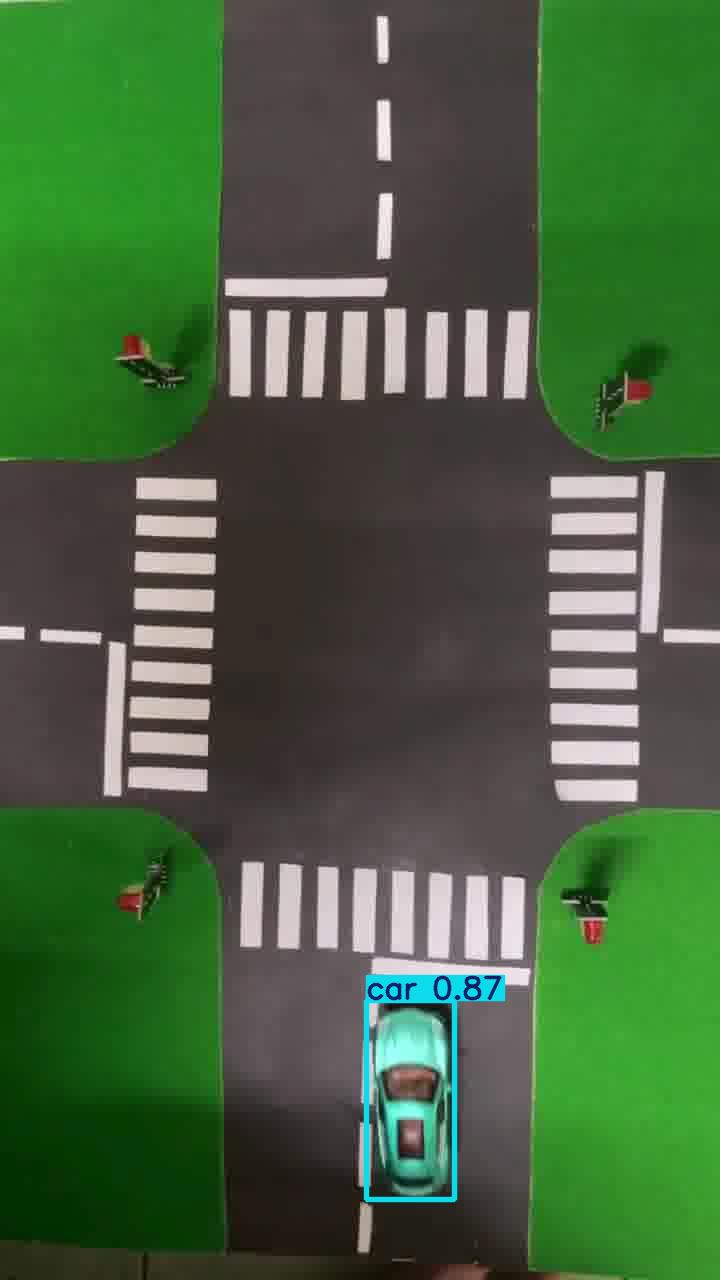

In [51]:
from ultralytics import YOLO
test_img = "/content/frame_00077_jpg.rf.qdFY8XcLmBRWFOCKVDyt.jpg"
model = YOLO("/content/vehicle_custom_best_320.pt")

results = model.predict(
    source=test_img,
    conf=0.5,
)
results[0].show()

In [ ]:
!mkdir -p frames_1

In [ ]:
!unzip video_toy.zip -d .

Archive:  video_toy.zip
  inflating: ./video_toy.mp4         


In [ ]:
!ffmpeg -i video_toy.mp4 frames_1/frame_%05d.jpg

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
!zip -r frames_1.zip frames_1

updating: frames_1/ (stored 0%)
updating: frames_1/frame_00111.jpg (deflated 3%)
updating: frames_1/frame_00190.jpg (deflated 3%)
updating: frames_1/frame_00304.jpg (deflated 3%)
updating: frames_1/frame_00313.jpg (deflated 3%)
updating: frames_1/frame_00001.jpg (deflated 1%)
updating: frames_1/frame_00093.jpg (deflated 3%)
updating: frames_1/frame_00290.jpg (deflated 3%)
updating: frames_1/frame_00292.jpg (deflated 3%)
updating: frames_1/frame_00177.jpg (deflated 2%)
updating: frames_1/frame_00102.jpg (deflated 3%)
updating: frames_1/frame_00054.jpg (deflated 3%)
updating: frames_1/frame_00178.jpg (deflated 2%)
updating: frames_1/frame_00251.jpg (deflated 3%)
updating: frames_1/frame_00184.jpg (deflated 3%)
updating: frames_1/frame_00179.jpg (deflated 3%)
updating: frames_1/frame_00165.jpg (deflated 2%)
updating: frames_1/frame_00120.jpg (deflated 3%)
updating: frames_1/frame_00164.jpg (deflated 2%)
updating: frames_1/frame_00187.jpg (deflated 3%)
updating: frames_1/frame_00029.jpg (d

In [ ]:
from google.colab import files
files.download('frames_1.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>